## The task

As a Data Analyst for Koala Conservation Research, your primary responsibility will be analysing a dataset that tracks the physical and biological characteristics of koalas. The dataset includes variables such as koala head length, skull width, and total length, alongside demographic information like age, gender, and habitat type. Your task will involve cleaning the dataset, visualising the data, conducting statistical analyses to identify key relationships among the variables, and drawing insights and conclusions from the analyses in particular to outline the linkage between the results and broader conservation outcomes.

## 1. Exploratory Data Analysis (EDA) and Cleansing

### 1.1  Exploratory Data Analysis (EDA)

In [2]:
# importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the dataset
koala_df = pd.read_excel('koalas_dataset.xlsx')
koala_df

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0
1,2,1,VIC,f,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0
2,3,1,VIC,f,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1,VIC,f,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1,VIC,f,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,QLD,m,1.0,16.5,69.5,14.5,11.8,16.0,11.0,1.8,58.0,52.0
100,101,7,q,m,1.0,19.0,70.5,13.6,13.0,14.4,9.7,1.0,60.0,58.0
101,102,7,QLD,f,6.0,18.0,77.0,17.4,10.4,13.5,10.0,0.6,60.0,55.0
102,103,7,QLD,m,4.0,16.5,70.5,16.5,10.9,12.9,10.2,2.4,60.0,54.0


In [4]:
# finding the shape of the dataframe
koala_df.shape

(104, 14)

In [5]:
# describing the data frame
koala_df.describe()

,koala_id,region,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,102.000000,103.000000,104.000000,104.000000,103.000000
mean,52.500000,3.625000,3.833333,17.009615,75.088462,18.554808,22.650000,18.461765,12.917476,5.886538,62.000000,57.582524
std,30.166206,2.349086,1.909244,1.959518,4.310549,9.761017,87.562416,4.416935,11.160491,39.082636,2.045597,2.775150
min,1.000000,1.000000,1.000000,12.000000,63.000000,7.500000,5.300000,10.300000,5.000000,0.500000,57.000000,50.000000
25%,26.750000,1.000000,2.250000,15.875000,72.000000,15.700000,9.875000,14.550000,9.950000,1.400000,60.500000,56.000000
50%,52.500000,3.000000,3.000000,17.000000,76.000000,17.850000,11.900000,17.950000,11.300000,1.900000,62.000000,57.500000
75%,78.250000,6.000000,5.000000,18.000000,78.000000,19.800000,17.025000,22.500000,13.100000,2.725000,63.000000,59.250000
max,104.000000,7.000000,9.000000,23.000000,84.500000,110.500000,900.800000,27.900000,120.600000,400.500000,67.000000,65.000000


In [6]:
# getting information about the data frame
koala_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   koala_id             104 non-null    int64  
 1   region               104 non-null    int64  
 2   habitat              104 non-null    object 
 3   gender               104 non-null    object 
 4   age_in_years         102 non-null    float64
 5   Paw Size             104 non-null    float64
 6   total_length         104 non-null    float64
 7   head_length          104 non-null    float64
 8   ear_size             104 non-null    float64
 9   foot_length          102 non-null    float64
 10  skull_width          103 non-null    float64
 11  eye_diameter         104 non-null    float64
 12  chest_circumference  104 non-null    float64
 13  belly_circumference  103 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


### 1.2 Replacing Missing values

In [7]:
# counting missing values in the data frame
age_missing_values = koala_df['age_in_years'].isna().sum()
print('Missing values in age column:',age_missing_values)

# counting missing values in the data frame
skull_missing_values = koala_df['skull_width'].isna().sum()
print('Missing values in skull width column:',skull_missing_values)

# counting missing values in the data frame
belly_missing_values = koala_df['belly_circumference'].isna().sum()
print('Missing values in belly circumference column:',belly_missing_values)

# counting missing values in the data frame
foot_missing_values = koala_df['foot_length'].isna().sum()
print('Missing values in foot length column:',foot_missing_values)

Missing values in age column: 2
Missing values in skull width column: 1
Missing values in belly circumference column: 1
Missing values in foot length column: 2


In [8]:
# Replacing the missing values with the median of the column in the dataframe
koala_df['age_in_years'].fillna(koala_df['age_in_years'].median(), inplace = True)

# Replacing the missing values with the median of the column in the dataframe
koala_df['skull_width'].fillna(koala_df['skull_width'].median(), inplace = True)

# Replacing the missing values with the median of the column in the dataframe
koala_df['belly_circumference'].fillna(koala_df['belly_circumference'].median(), inplace = True)

# Replacing the missing values with the median of the column in the dataframe
koala_df['foot_length'].fillna(koala_df['foot_length'].median(), inplace = True)

### 1.3 Identifying and Correcting wrong entries

In [9]:
# checking if regions are correct
region = koala_df['region'].unique().tolist()
print('Unique elements in region:')
region

Unique elements in region:


[1, 2, 3, 4, 5, 6, 7]

In [10]:
# checking if habitats are correct
habitat = koala_df['habitat'].unique().tolist()
print('Unique elements in habitat:')
habitat

Unique elements in habitat:


['VIC', 'VICtoria', 'Vic', 'QLD', 'Queensland', 'Queenstown', 'qld', 'q']

In [11]:
# checking if genders are correct
gender = koala_df['gender'].unique().tolist()
print('Unique elements in gender:')
gender

Unique elements in gender:


['m', 'f', 'female', 'male']

In [12]:
# rectifying the errors in habitat
habitat_corrections = {'VICtoria': 'VIC', 'Vic': 'VIC', 'Queensland': 'QLD', 'Queenstown': 'QLD', 'qld': 'QLD', 'q': 'QLD'}

#use replace to replace the previous values with correct values
koala_df['habitat'] = koala_df['habitat'].replace(habitat_corrections)

In [13]:
# rectifying the errors in gender
gender_corrections = {'female': 'f', 'male': 'm'}

#use replace to replace the previous values with correct values
koala_df['gender'] = koala_df['gender'].replace(gender_corrections)

### 1.4 Removing Duplicates

In [14]:
# code to identify the duplicate values in the koala_id field
koala_duplicates = koala_df['koala_id'].duplicated(keep=False)
duplicate_rows = koala_df[koala_duplicates]

In [15]:
# Now, duplicate_rows contains only the rows where koala_id has duplicates
duplicate_rows

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference


### 1.5 Outlier Treatment

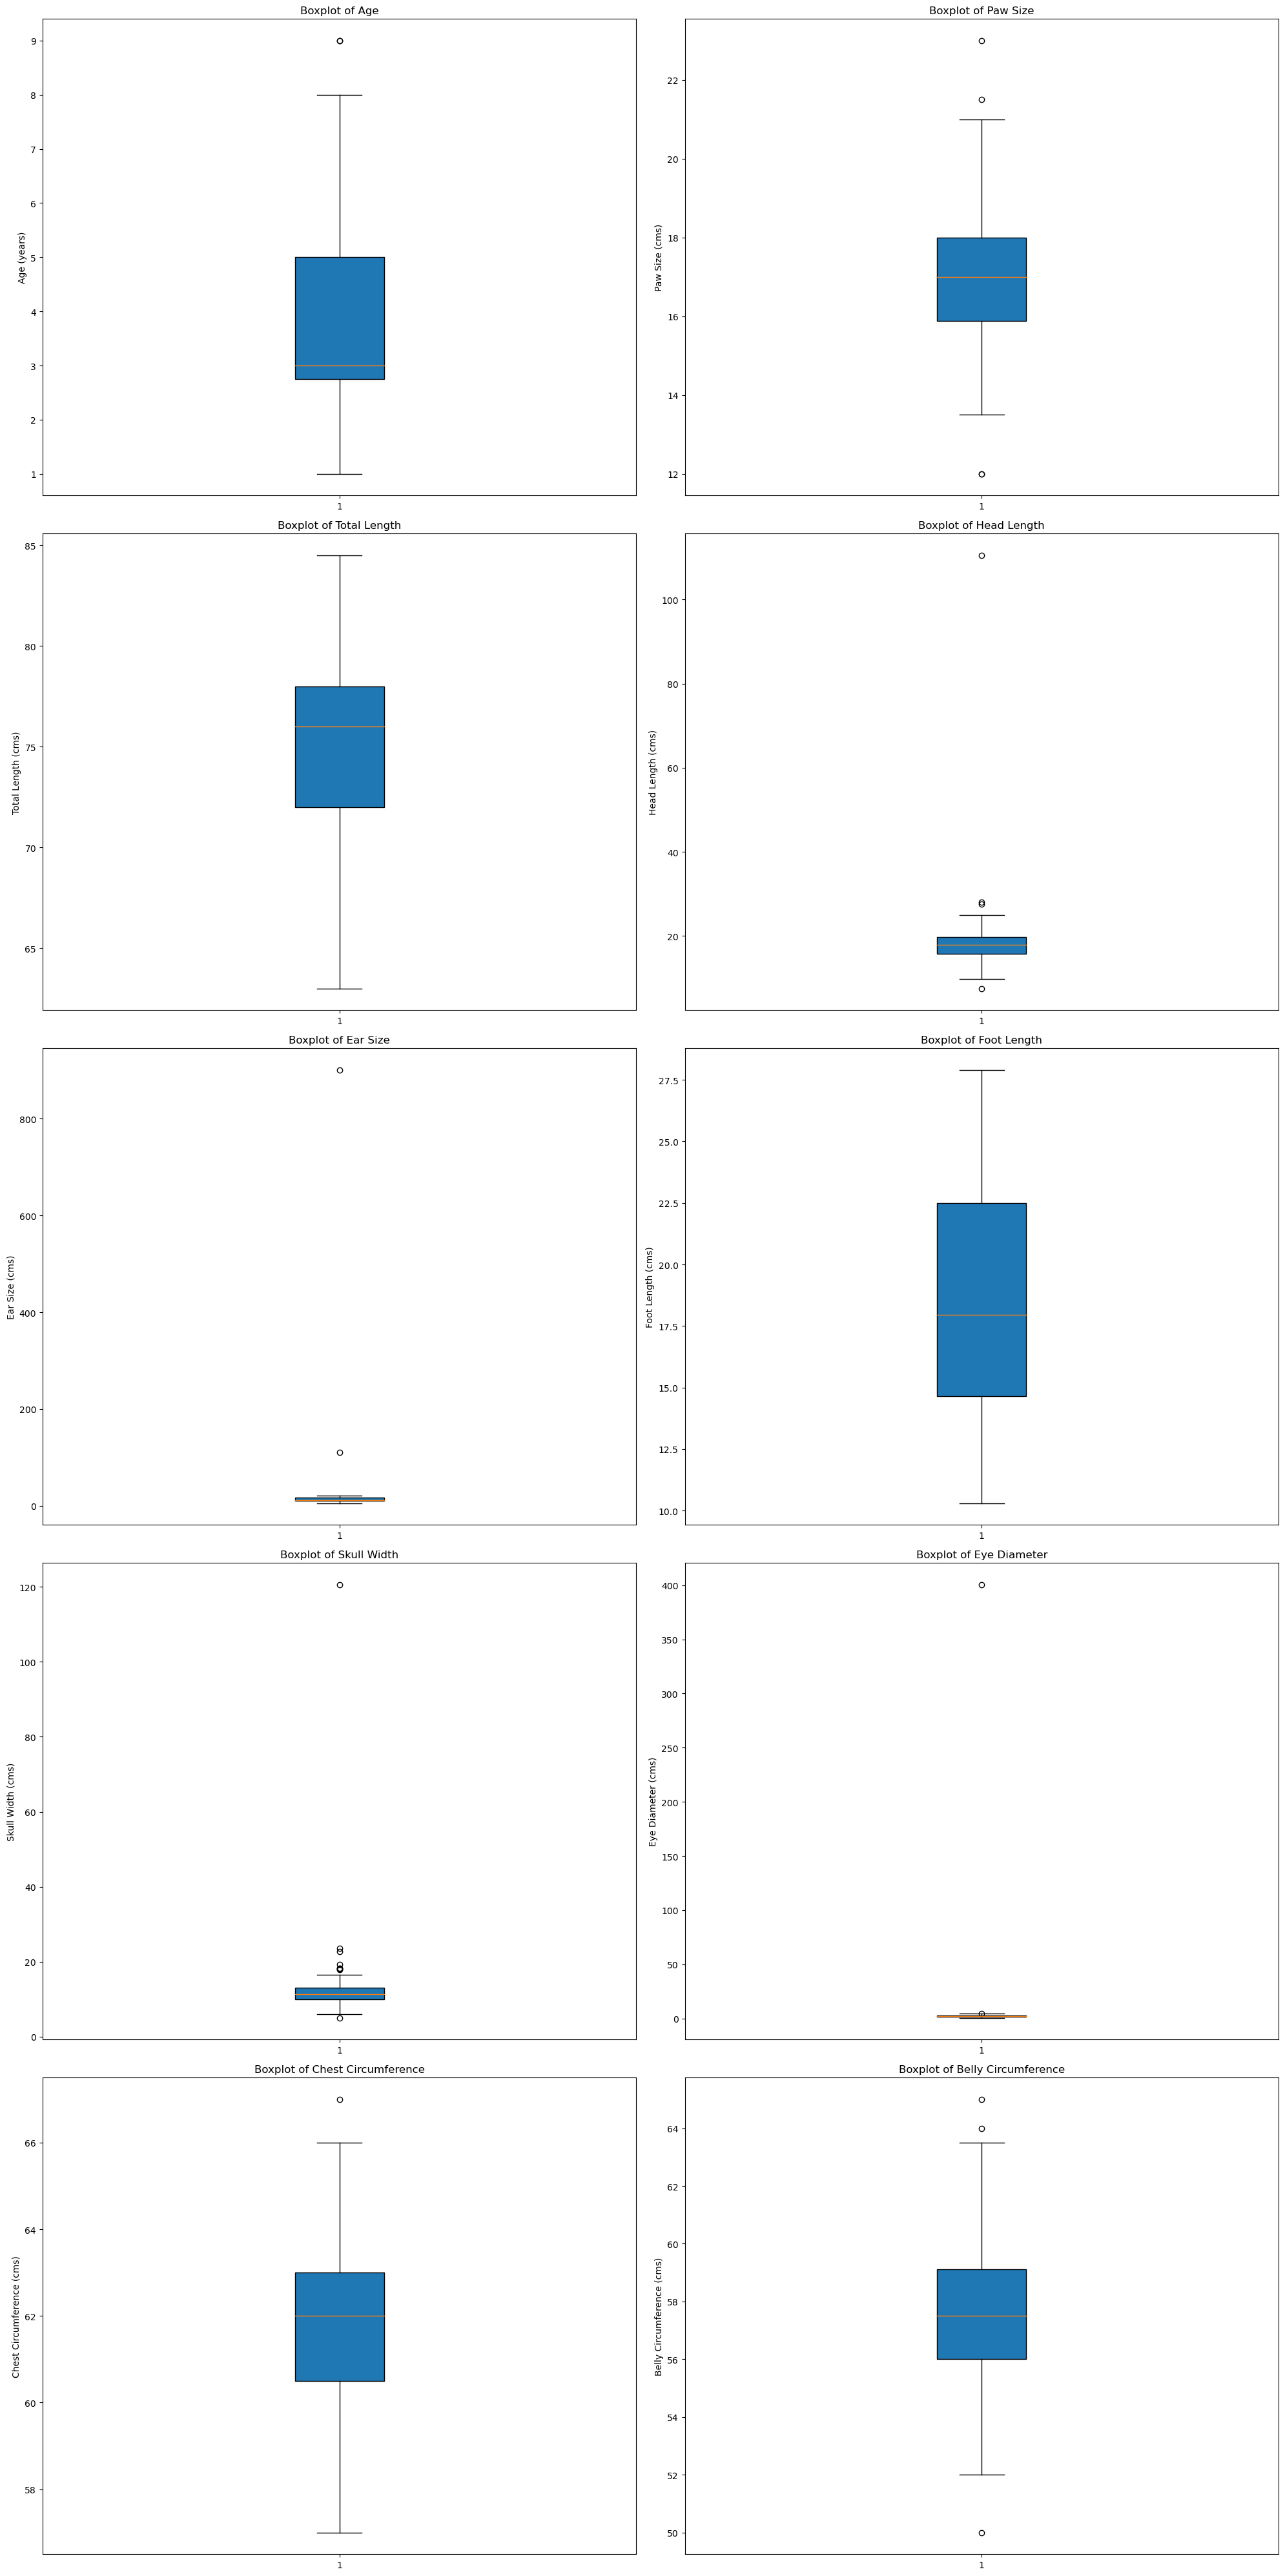

In [16]:
# box plot to identify outliers in the data 
plt.figure(figsize=(20, 40))

# Age boxplot
plt.subplot(5, 2, 1)
plt.boxplot(koala_df['age_in_years'], patch_artist=True)
plt.title('Boxplot of Age')
plt.ylabel('Age (years)')

# Paw SIze boxplot
plt.subplot(5, 2, 2)
plt.boxplot(koala_df['Paw Size'], patch_artist=True)
plt.title('Boxplot of Paw Size')
plt.ylabel('Paw Size (cms)')

# Total Length boxplot
plt.subplot(5, 2, 3)
plt.boxplot(koala_df['total_length'], patch_artist=True)
plt.title('Boxplot of Total Length')
plt.ylabel('Total Length (cms)')

# Head Length boxplot
plt.subplot(5, 2, 4)
plt.boxplot(koala_df['head_length'], patch_artist=True)
plt.title('Boxplot of Head Length')
plt.ylabel('Head Length (cms)')

# Ear SIze boxplot
plt.subplot(5, 2, 5)
plt.boxplot(koala_df['ear_size'], patch_artist=True)
plt.title('Boxplot of Ear Size')
plt.ylabel('Ear Size (cms)')

# Foot Length boxplot
plt.subplot(5, 2, 6)
plt.boxplot(koala_df['foot_length'], patch_artist=True)
plt.title('Boxplot of Foot Length')
plt.ylabel('Foot Length (cms)')

# Skull Width boxplot
plt.subplot(5, 2, 7)
plt.boxplot(koala_df['skull_width'], patch_artist=True)
plt.title('Boxplot of Skull Width')
plt.ylabel('Skull Width (cms)')

# Eye Diameter boxplot
plt.subplot(5, 2, 8)
plt.boxplot(koala_df['eye_diameter'], patch_artist=True)
plt.title('Boxplot of Eye Diameter')
plt.ylabel('Eye Diameter (cms)')

# Chest Circumference boxplot
plt.subplot(5, 2, 9)
plt.boxplot(koala_df['chest_circumference'], patch_artist=True)
plt.title('Boxplot of Chest Circumference')
plt.ylabel('Chest Circumference (cms)')

# Belly Circumference boxplot
plt.subplot(5, 2, 10)
plt.boxplot(koala_df['belly_circumference'], patch_artist=True)
plt.title('Boxplot of Belly Circumference')
plt.ylabel('Belly Circumference (cms)')

plt.tight_layout()
plt.show()

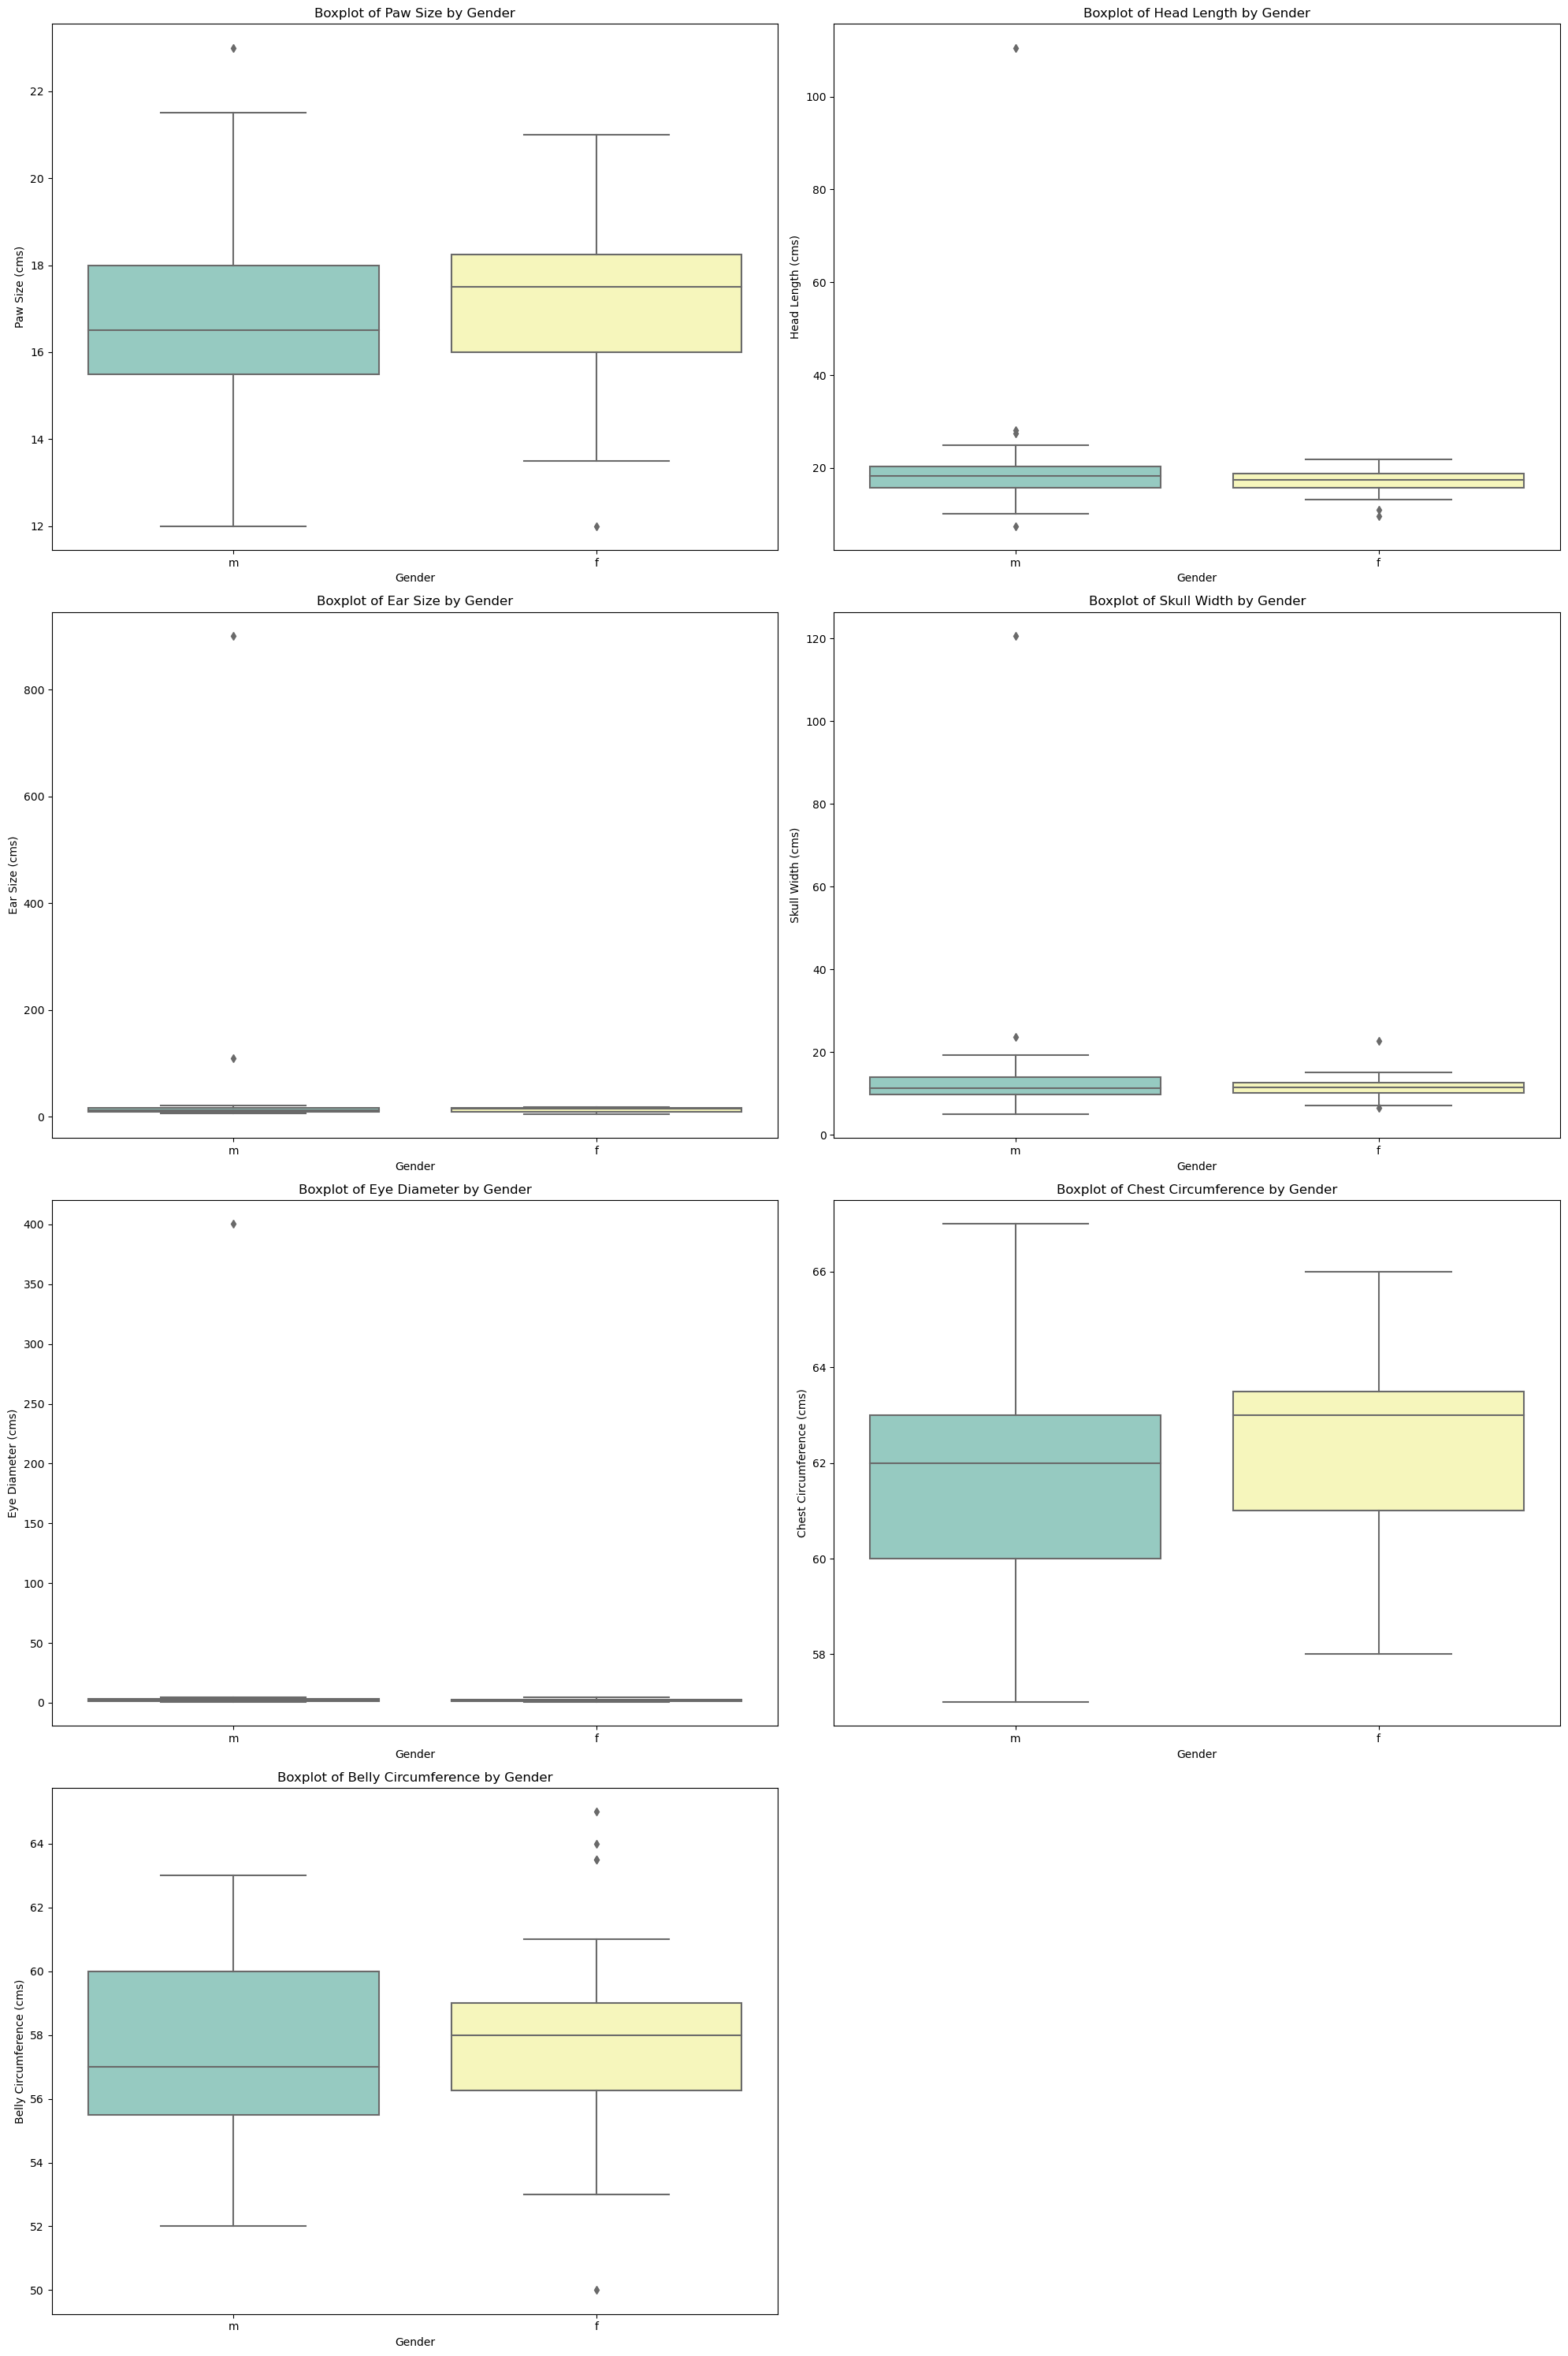

In [17]:
# box plot to identify outliers in the data 
plt.figure(figsize=(20, 30))

# using a paw size by gender boxplot to understand the data better
plt.subplot(4, 2, 1)
sns.boxplot(data = koala_df, x = 'gender', y = 'Paw Size',palette = 'Set3')
plt.title('Boxplot of Paw Size by Gender')
plt.xlabel('Gender')
plt.ylabel('Paw Size (cms)')

# using a head_length by gender boxplot to understand the data better
plt.subplot(4, 2, 2)
sns.boxplot(data = koala_df, x = 'gender', y = 'head_length',palette = 'Set3')
plt.title('Boxplot of Head Length by Gender')
plt.xlabel('Gender')
plt.ylabel('Head Length (cms)')

# using a ear_size by gender boxplot to understand the data better
plt.subplot(4, 2, 3)
sns.boxplot(data = koala_df, x = 'gender', y = 'ear_size',palette = 'Set3')
plt.title('Boxplot of Ear Size by Gender')
plt.xlabel('Gender')
plt.ylabel('Ear Size (cms)')

# using a skull_width by gender boxplot to understand the data better
plt.subplot(4, 2, 4)
sns.boxplot(data = koala_df, x = 'gender', y = 'skull_width',palette = 'Set3')
plt.title('Boxplot of Skull Width by Gender')
plt.xlabel('Gender')
plt.ylabel('Skull Width (cms)')

# using a eye_diameter by gender boxplot to understand the data better
plt.subplot(4, 2, 5)
sns.boxplot(data = koala_df, x = 'gender', y = 'eye_diameter',palette = 'Set3')
plt.title('Boxplot of Eye Diameter by Gender')
plt.xlabel('Gender')
plt.ylabel('Eye Diameter (cms)')

# using a chest_circumference by gender boxplot to understand the data better
plt.subplot(4, 2, 6)
sns.boxplot(data = koala_df, x = 'gender', y = 'chest_circumference',palette = 'Set3')
plt.title('Boxplot of Chest Circumference by Gender')
plt.xlabel('Gender')
plt.ylabel('Chest Circumference (cms)')

# using a belly_circumference by gender boxplot to understand the data better
plt.subplot(4, 2, 7)
sns.boxplot(data = koala_df, x = 'gender', y = 'belly_circumference',palette = 'Set3')
plt.title('Boxplot of Belly Circumference by Gender')
plt.xlabel('Gender')
plt.ylabel('Belly Circumference (cms)')


plt.tight_layout()
plt.show()

In [18]:
# replacing outliers from paw size 

# Calculate 25th and 75th percentiles, and the interquartile range for the 'Paw Size' column
percentile25 = koala_df['Paw Size'].quantile(0.25)
percentile75 = koala_df['Paw Size'].quantile(0.75)
iqr = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Calculate the mean of non-outlier data
mean_value = koala_df[(koala_df['Paw Size'] >= lower_limit) & (koala_df['Paw Size'] <= upper_limit)]['Paw Size'].mean()

# Identify the outliers to count them before replacing
outliers = (koala_df['Paw Size'] < lower_limit) | (koala_df['Paw Size'] > upper_limit)

# Count the number of outliers
num_outliers = outliers.sum()

# Replace outliers with the mean value
koala_df['Paw Size'] = koala_df['Paw Size'].mask(outliers, mean_value)

# Display the number of outliers replaced
print(f"Number of outliers replaced from paw size: {num_outliers}")

Number of outliers replaced from paw size: 4


In [19]:
# replacing outliers from head length

# Calculate 25th and 75th percentiles, and the interquartile range for the 'Paw Size' column
percentile25 = koala_df['head_length'].quantile(0.25)
percentile75 = koala_df['head_length'].quantile(0.75)
iqr = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Calculate the mean of non-outlier data
mean_value = koala_df[(koala_df['head_length'] >= lower_limit) & (koala_df['head_length'] <= upper_limit)]['head_length'].mean()

# Identify the outliers to count them before replacing
outliers = (koala_df['head_length'] < lower_limit) | (koala_df['head_length'] > upper_limit)

# Count the number of outliers
num_outliers = outliers.sum()

# Replace outliers with the mean value
koala_df['head_length'] = koala_df['head_length'].mask(outliers, mean_value)

# Display the number of outliers replaced
print(f"Number of outliers replaced from head length: {num_outliers}")

Number of outliers replaced from head length: 4


In [20]:
# replacing outliers from ear size

# Calculate 25th and 75th percentiles, and the interquartile range for the 'Paw Size' column
percentile25 = koala_df['ear_size'].quantile(0.25)
percentile75 = koala_df['ear_size'].quantile(0.75)
iqr = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Calculate the mean of non-outlier data
mean_value = koala_df[(koala_df['ear_size'] >= lower_limit) & (koala_df['ear_size'] <= upper_limit)]['ear_size'].mean()

# Identify the outliers to count them before replacing
outliers = (koala_df['ear_size'] < lower_limit) | (koala_df['ear_size'] > upper_limit)

# Count the number of outliers
num_outliers = outliers.sum()

# Replace outliers with the mean value
koala_df['ear_size'] = koala_df['ear_size'].mask(outliers, mean_value)

# Display the number of outliers replaced
print(f"Number of outliers replaced from ear size: {num_outliers}")

Number of outliers replaced from ear size: 2


In [21]:
# replacing outliers from skull width

# Calculate 25th and 75th percentiles, and the interquartile range for the 'Paw Size' column
percentile25 = koala_df['skull_width'].quantile(0.25)
percentile75 = koala_df['skull_width'].quantile(0.75)
iqr = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Calculate the mean of non-outlier data
mean_value = koala_df[(koala_df['skull_width'] >= lower_limit) & (koala_df['skull_width'] <= upper_limit)]['skull_width'].mean()

# Identify the outliers to count them before replacing
outliers = (koala_df['skull_width'] < lower_limit) | (koala_df['skull_width'] > upper_limit)

# Count the number of outliers
num_outliers = outliers.sum()

# Replace outliers with the mean value
koala_df['skull_width'] = koala_df['skull_width'].mask(outliers, mean_value)

# Display the number of outliers replaced
print(f"Number of outliers replaced from skull width: {num_outliers}")

Number of outliers replaced from skull width: 9


In [22]:
# replacing outliers from eye diameter

# Calculate 25th and 75th percentiles, and the interquartile range for the 'Paw Size' column
percentile25 = koala_df['eye_diameter'].quantile(0.25)
percentile75 = koala_df['eye_diameter'].quantile(0.75)
iqr = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Calculate the mean of non-outlier data
mean_value = koala_df[(koala_df['eye_diameter'] >= lower_limit) & (koala_df['eye_diameter'] <= upper_limit)]['eye_diameter'].mean()

# Identify the outliers to count them before replacing
outliers = (koala_df['eye_diameter'] < lower_limit) | (koala_df['eye_diameter'] > upper_limit)

# Count the number of outliers
num_outliers = outliers.sum()

# Replace outliers with the mean value
koala_df['eye_diameter'] = koala_df['eye_diameter'].mask(outliers, mean_value)

# Display the number of outliers replaced
print(f"Number of outliers replaced from eye diameter: {num_outliers}")

Number of outliers replaced from eye diameter: 2


In [23]:
# replacing outliers from belly circumferece

# Calculate 25th and 75th percentiles, and the interquartile range for the 'Paw Size' column
percentile25 = koala_df['belly_circumference'].quantile(0.25)
percentile75 = koala_df['belly_circumference'].quantile(0.75)
iqr = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Calculate the mean of non-outlier data
mean_value = koala_df[(koala_df['belly_circumference'] >= lower_limit) & (koala_df['belly_circumference'] <= upper_limit)]['belly_circumference'].mean()

# Identify the outliers to count them before replacing
outliers = (koala_df['belly_circumference'] < lower_limit) | (koala_df['belly_circumference'] > upper_limit)

# Count the number of outliers
num_outliers = outliers.sum()

# Replace outliers with the mean value
koala_df['belly_circumference'] = koala_df['belly_circumference'].mask(outliers, mean_value)

# Display the number of outliers replaced
print(f"Number of outliers replaced from belly circumference: {num_outliers}")

Number of outliers replaced from belly circumference: 3


### 1.6 Checking distribution and skewness of the data using histogram

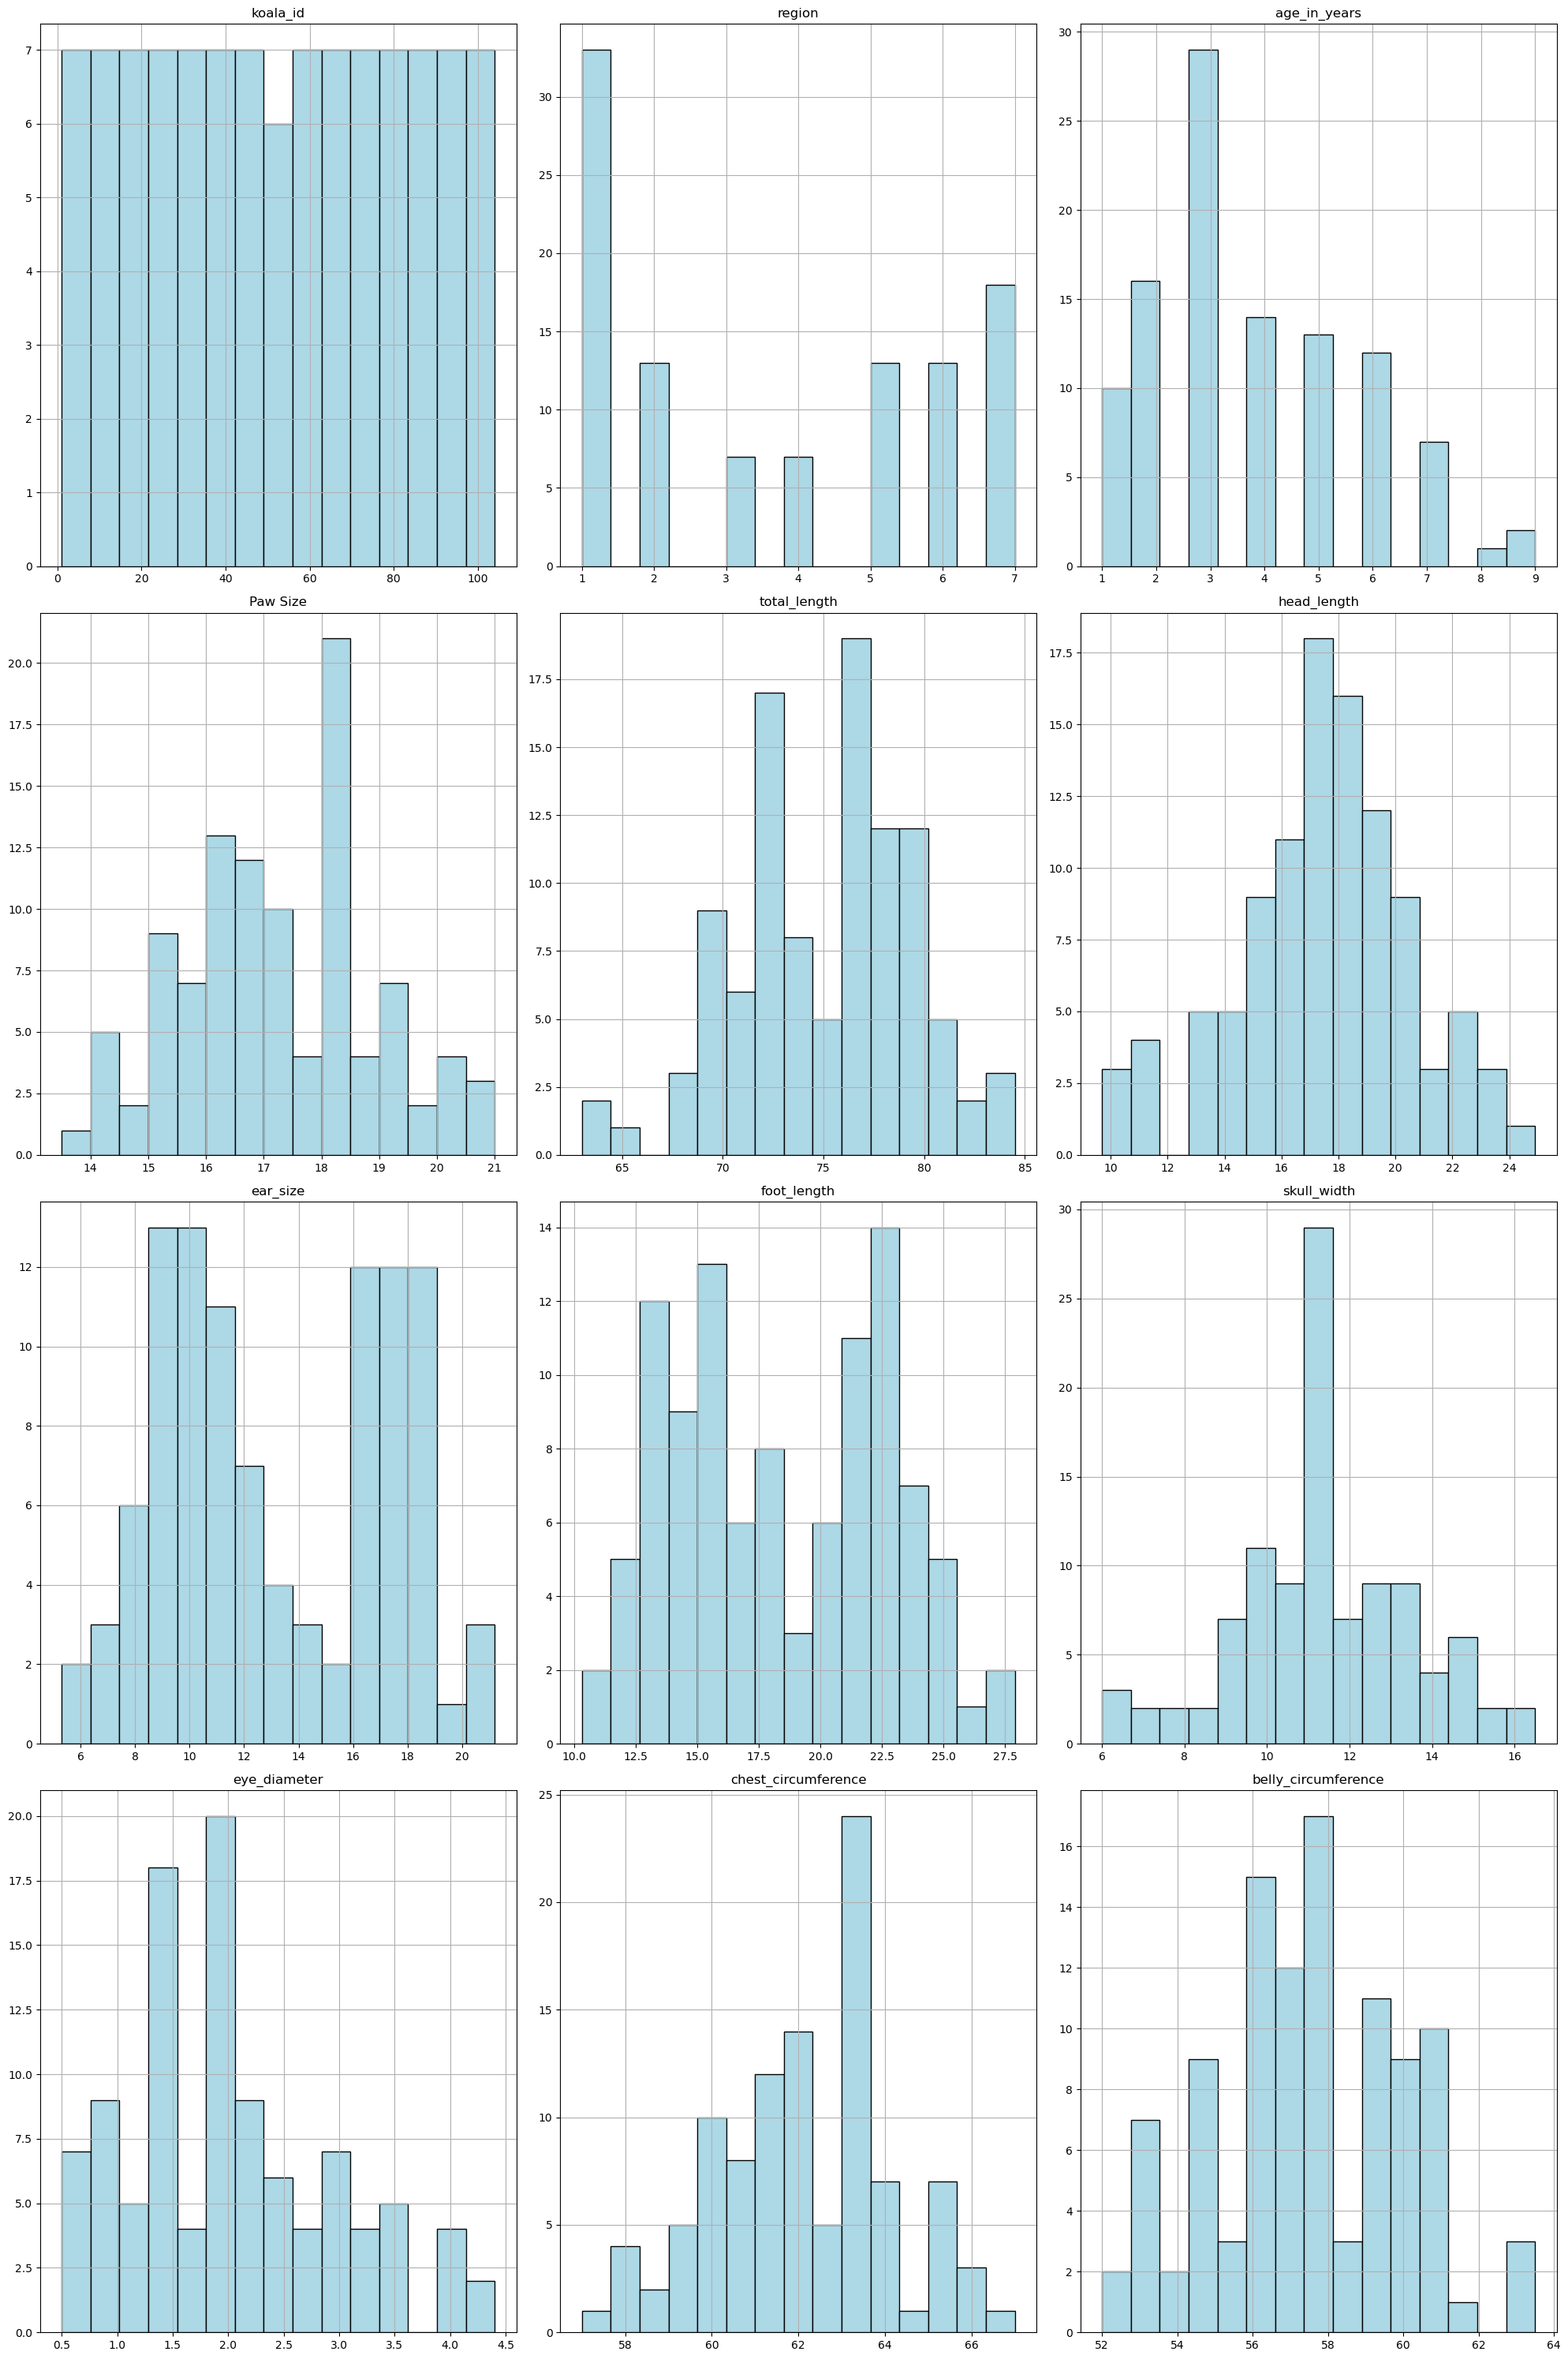

In [24]:
# Create histograms for all numerical columns
koala_df.hist(bins=15, figsize=(20, 30), edgecolor='black', color = 'lightblue')

# Display the histograms
plt.tight_layout()
plt.show()


In [25]:
# measuring skewness of the data
age_skew = koala_df['age_in_years'].skew()
print('Age Skew:',age_skew)

paw_skew = koala_df['Paw Size'].skew()
print('Paw Size Skew:',paw_skew)

total_length_skew = koala_df['total_length'].skew()
print('Total Length Skew:',total_length_skew)

head_skew = koala_df['head_length'].skew()
print('Head Length Skew:',head_skew)

ear_skew = koala_df['ear_size'].skew()
print('Ear Size Skew:',ear_skew)

foot_skew = koala_df['foot_length'].skew()
print('Foot Length Skew:',foot_skew)

skull_skew = koala_df['skull_width'].skew()
print('Skull Width Skew:',skull_skew)

eye_skew = koala_df['eye_diameter'].skew()
print('Eye Diameter Skew:',eye_skew)

chest_skew = koala_df['chest_circumference'].skew()
print('Chest Circumference Skew:',chest_skew)

belly_skew = koala_df['belly_circumference'].skew()
print('Belly Circumference Skew:',belly_skew)

Age Skew: 0.5654509623469088
Paw Size Skew: 0.16309937307797584
Total Length Skew: -0.285265771534212
Head Length Skew: -0.34521550126719874
Ear Size Skew: 0.12573618443738843
Foot Length Skew: 0.09752005197842935
Skull Width Skew: -0.06423266613075483
Eye Diameter Skew: 0.5655892783247332
Chest Circumference Skew: -0.05551075216583214
Belly Circumference Skew: 0.032108623721233125


## 2. Data Visualisation

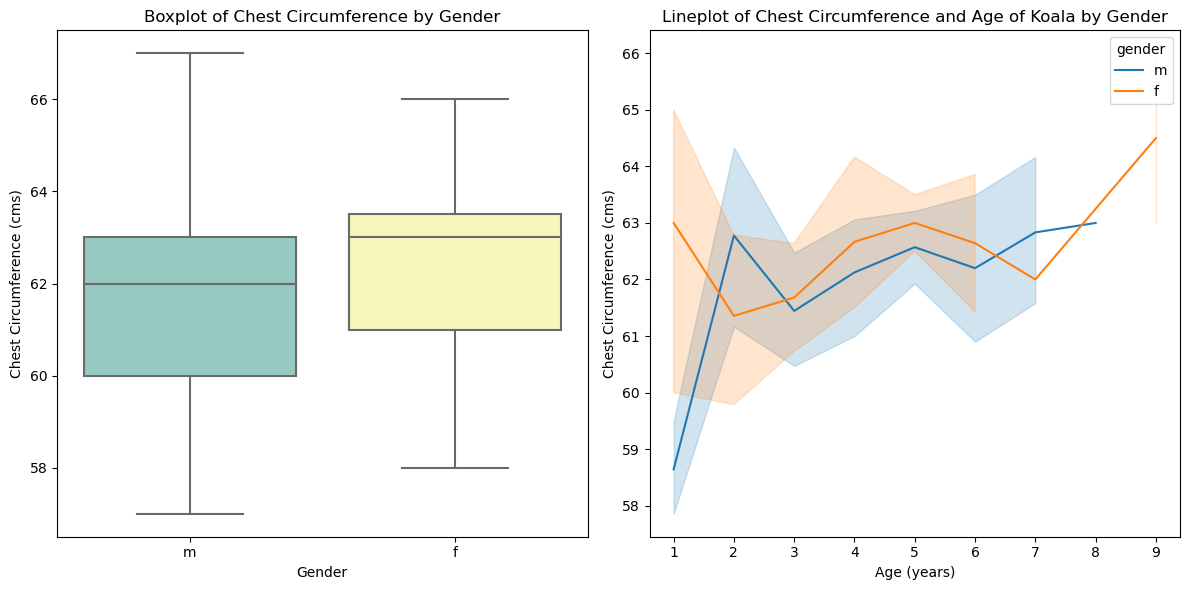

In [26]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Create Box plot
plt.subplot(1,2,1)
sns.boxplot(data = koala_df, x = 'gender', y = 'chest_circumference',palette = 'Set3')
plt.title('Boxplot of Chest Circumference by Gender')
plt.xlabel('Gender')
plt.ylabel('Chest Circumference (cms)')

# Create line plot
plt.subplot(1,2,2)
sns.lineplot(data=koala_df, x='age_in_years', y='chest_circumference', hue='gender')
plt.title('Lineplot of Chest Circumference and Age of Koala by Gender')
plt.xlabel('Age (years)')
plt.ylabel('Chest Circumference (cms)')

# Show the plot
plt.tight_layout()
plt.show()

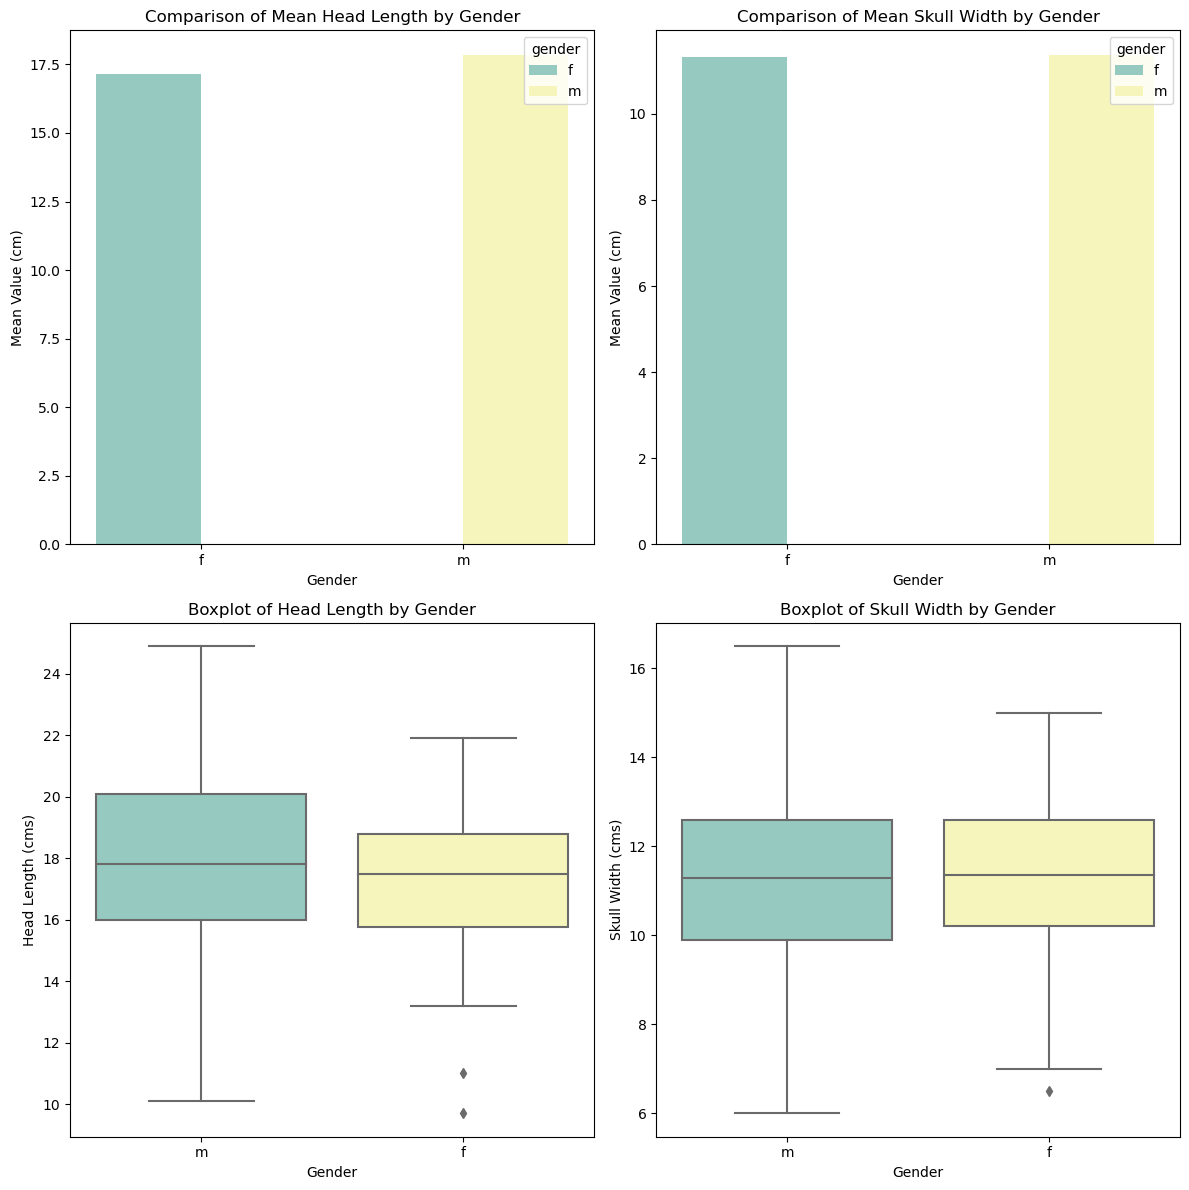

In [27]:
# finding mean value sof headlength and skull width by gender
mean_values = koala_df.groupby('gender')[['head_length', 'skull_width']].mean().reset_index()

# Set the figure size
plt.figure(figsize=(12, 12))

# Create barplot
plt.subplot(2,2,1)
sns.barplot(data = mean_values, x='gender', y='head_length', hue='gender', palette='Set3')
plt.title('Comparison of Mean Head Length by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Value (cm)')

# Create barplot
plt.subplot(2,2,2)
sns.barplot(data = mean_values, x='gender', y='skull_width', hue='gender', palette='Set3')
plt.title('Comparison of Mean Skull Width by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Value (cm)')

# Create boxplot
plt.subplot(2,2,3)
sns.boxplot(data = koala_df, x = 'gender', y = 'head_length',palette = 'Set3')
plt.title('Boxplot of Head Length by Gender')
plt.xlabel('Gender')
plt.ylabel('Head Length (cms)')

# Create boxplot
plt.subplot(2,2,4)
sns.boxplot(data = koala_df, x = 'gender', y = 'skull_width',palette = 'Set3')
plt.title('Boxplot of Skull Width by Gender')
plt.xlabel('Gender')
plt.ylabel('Skull Width (cms)')

# Show the plot
plt.tight_layout()
plt.show()


## 3. Analysis

### 3.1 Is the mean head length of the Koalas significantly different from 92.0 mm or 9.2 cm?

#### Step 1: State the Null Hypothesis and the Alternative Hypothesis

Null Hypothesis (H0): The mean head length of koalas is 9.2 cm. (μ = 9.2)

Alternative Hypothesis (Ha): The mean head length of koalas is different from 9.2 cm. (μ ≠ 9.2)

#### Step 2: Choose a Significance Level

We'll use a significance level of 0.05 (5%).

#### Step 3: Perform the test

We will go with 1 sample t-test to test our hypotheses.

In [28]:
from scipy import stats

# Hypothesized population mean
population_mean = 9.2

# Perform a one-sample t-test
t_statistic, p_value = stats.ttest_1samp(koala_df['head_length'], population_mean)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 27.8198653604521
p-value: 1.0449434268947893e-49


#### Step 4: Reject or Fail to Reject the Null Hypothesis


In [29]:
# Significance level
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. The mean head length of koalas is significantly different from 9.2 cm.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of koalas is significantly different from 9.2 cm.")


Reject the null hypothesis. The mean head length of koalas is significantly different from 9.2 cm.


### 3.2 Do male and female Koalas have significantly different mean head lengths?

#### Step 1: State the Null Hypothesis and the Alternative Hypothesis

Null Hypothesis (H0): The mean head length of male and female koalas are equal. (μA = μB)

Alternative Hypothesis (Ha): The mean head length of male and female koalas are different. (μA ≠ μB)

#### Step 2: Choose a Significance Level

We’ll use a significance level of 0.05 (5%).

#### Step 3: Perform the test
We will go with independent two sample t-test to test our hypotheses.

In [30]:
# Separate the head_length by gender
male_head_length = koala_df[koala_df['gender'] == 'm']['head_length']
female_head_length = koala_df[koala_df['gender'] == 'f']['head_length']

# Perform a two-sample t-test
t_statistic, p_value = stats.ttest_ind(male_head_length, female_head_length)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 1.1532661440581395
p-value: 0.25149651766599


#### Step 4: Reject or Fail to Reject the Null Hypothesis


In [31]:
# Significance level
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean head length of male and female koalas.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of male and female koalas are different.")


Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of male and female koalas are different.


### 3.3 Can we predict the total length of a Koala based on its head length?

In [32]:
# Subset of Data
ols_data = koala_df[["head_length", "total_length"]]

In [33]:
# Write out formula  = Y~X
ols_formula = "total_length ~ head_length"

In [34]:
# Build OLS, fit model to data
from statsmodels.formula.api import ols
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           total_length   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     68.55
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           5.04e-13
Time:                        23:08:24   Log-Likelihood:                -272.29
No. Observations:                 104   AIC:                             548.6
Df Residuals:                     102   BIC:                             553.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      59.4300      1.919     30.961      0.000      55.623      63.237
head_length     0.8917      0.108      8.280      0.000       0.678       1.105
==============================================================================
Omnibus:                        0.050   Durbin-Watson:                   1.580
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.170
Skew:                           0.043   Prob(JB):                        0.919
Kurtosis:                       2.822   Cond. No.                         104.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 3.4 Can we predict the total length of a Koala based on multiple factors such as head length, skull width, and foot length?

In [35]:
# Define the independent variables (features) and the dependent variable (target)
X = koala_df[['head_length', 'skull_width', 'foot_length']]
y = koala_df['total_length']

In [36]:
import statsmodels.api as sm
# Fit the multiple regression model
model = sm.OLS(y, X).fit()

# Display the summary of the regression model
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:           total_length   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              2384.
Date:                Mon, 14 Oct 2024   Prob (F-statistic):                    1.46e-93
Time:                        23:08:24   Log-Likelihood:                         -374.63
No. Observations:                 104   AIC:                                      755.3
Df Residuals:                     101   BIC:                                      763.2
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
head_length     1.8723      0.363      5.165      0.000       1.153       2.591
skull_width     2.1344      0.532      4.013      0.000       1.079       3.189
foot_length     0.9057      0.205      4.414      0.000       0.499       1.313
==============================================================================
Omnibus:                        2.185   Durbin-Watson:                   1.513
Prob(Omnibus):                  0.335   Jarque-Bera (JB):                2.204
Skew:                           0.334   Prob(JB):                        0.332
Kurtosis:                       2.749   Cond. No.                         19.7
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 3.5 Do environmental factors such as state affect Koala’s physical characteristics?

#### One-hot encoding of categorical variables

In [37]:
# defining the categorical columns
categorical_cols = ['habitat']

# Perform one-hot encoding on the 'habitat' column, dropping the first category
koala_df_encoded = pd.get_dummies(koala_df, columns=categorical_cols, drop_first=True)

# Identify the one-hot encoded columns related to 'habitat'
habitat_encoded_cols = [col for col in koala_df_encoded.columns if 'habitat' in col]

# Convert the 'habitat' one-hot encoded columns to integers
koala_df_encoded[habitat_encoded_cols] = koala_df_encoded[habitat_encoded_cols].astype(int)

# Display the first few rows of the encoded DataFrame
koala_df_encoded.head()


,koala_id,region,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference,habitat_VIC
0,1,1,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0,1
1,2,1,f,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0,1
2,3,1,f,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0,1
3,4,1,f,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0,1
4,5,1,f,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0,1


In [38]:
# Compute the correlation matrix
correlation_matrix = koala_df_encoded.corr(numeric_only = True)[['habitat_VIC', 'region']]
correlation_matrix

,habitat_VIC,region
koala_id,-0.860281,0.970353
region,-0.892326,1.000000
age_in_years,0.076043,-0.124648
Paw Size,-0.455299,0.361783
total_length,0.078666,-0.260843
head_length,0.010752,-0.163082
ear_size,0.876106,-0.781800
foot_length,0.787426,-0.780625
skull_width,0.011799,-0.135372
eye_diameter,-0.128282,-0.055483


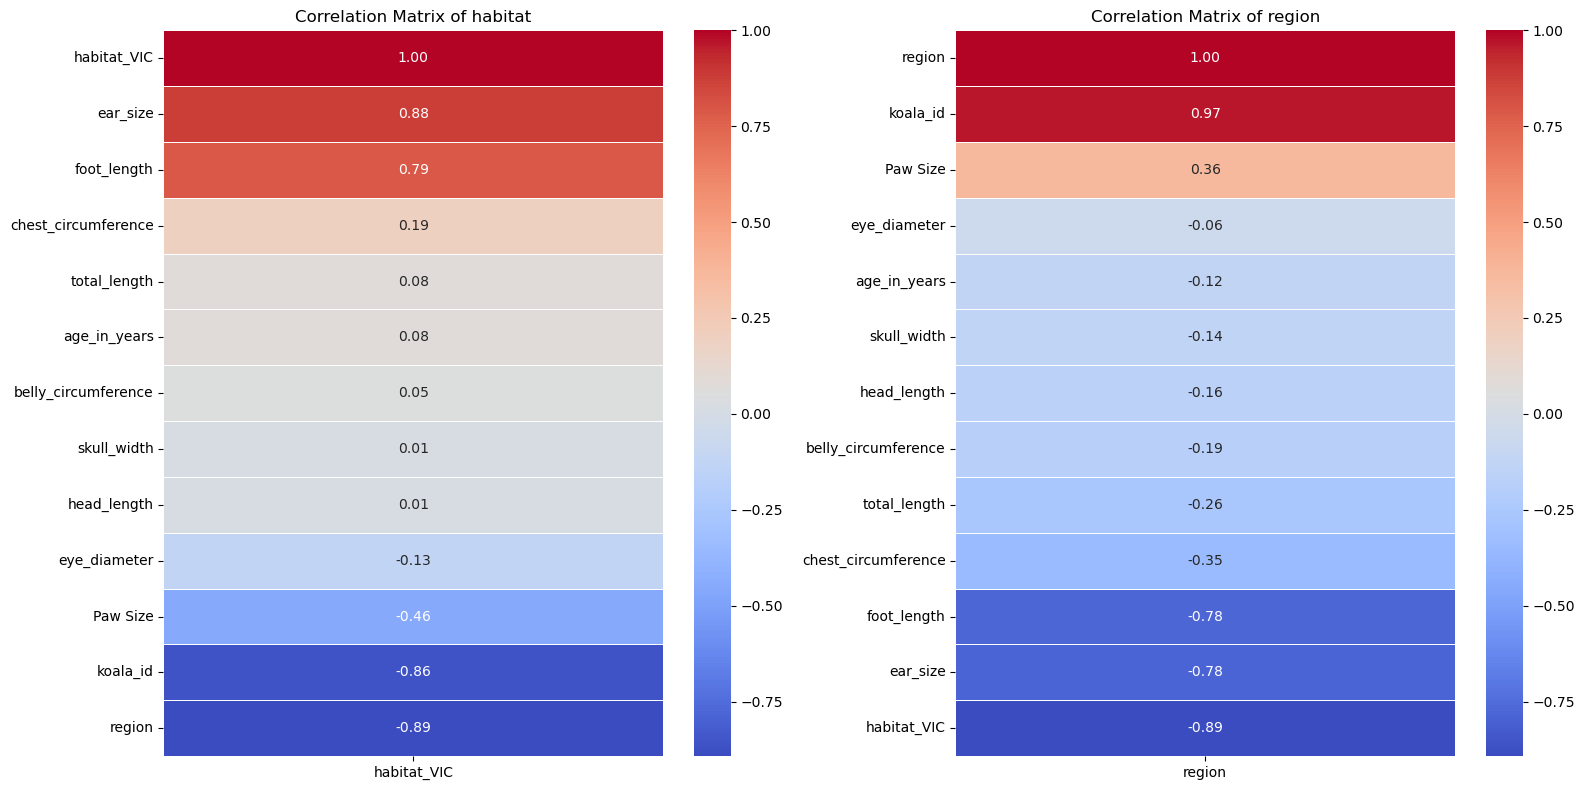

In [39]:
# Set up the matplotlib figure
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.heatmap(correlation_matrix[['habitat_VIC']].sort_values(by='habitat_VIC', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of habitat')

plt.subplot(1,2,2)
sns.heatmap(correlation_matrix[['region']].sort_values(by='region', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of region')

plt.tight_layout()
plt.show()

In [40]:
# using a for loop to conduct two sample t-test of physical characteristics

# List of characteristics
characteristics = ['Paw Size', 'total_length', 'head_length', 'ear_size', 'foot_length', 
                   'skull_width', 'eye_diameter', 'chest_circumference', 'belly_circumference']

# Iterate over each characteristic
for characteristic in characteristics:
    # Separate the data for the two habitats (QLD and VIC)
    qld_data = koala_df[koala_df['habitat'] == 'QLD'][characteristic]
    vic_data = koala_df[koala_df['habitat'] == 'VIC'][characteristic]

    # Perform a two-sample t-test
    t_statistic, p_value = stats.ttest_ind(qld_data, vic_data)
    print(f"The p-value for the difference in {characteristic} is: {p_value}")

The p-value for the difference in Paw Size is: 1.1972304112976106e-06
The p-value for the difference in total_length is: 0.42732483754563677
The p-value for the difference in head_length is: 0.9137342907194617
The p-value for the difference in ear_size is: 4.310122908998822e-34
The p-value for the difference in foot_length is: 3.6686285351077066e-23
The p-value for the difference in skull_width is: 0.9053734858687188
The p-value for the difference in eye_diameter is: 0.19436256278718989
The p-value for the difference in chest_circumference is: 0.047342464272094396
The p-value for the difference in belly_circumference is: 0.5995400512711424


### 3.6 What factors are correlated with the total length of a Koala?

In [41]:
# Calculate the correlation matrix
corr_matrix = koala_df.corr(numeric_only = True)[['total_length']]
# Sort the correlation values in descending order
corr_matrix_sorted = corr_matrix.sort_values(by='total_length', ascending=False)

corr_matrix_sorted

,total_length
total_length,1.000000
head_length,0.633996
skull_width,0.602754
chest_circumference,0.577890
Paw Size,0.481338
foot_length,0.443706
belly_circumference,0.397006
age_in_years,0.264556
eye_diameter,0.207063
ear_size,0.155072


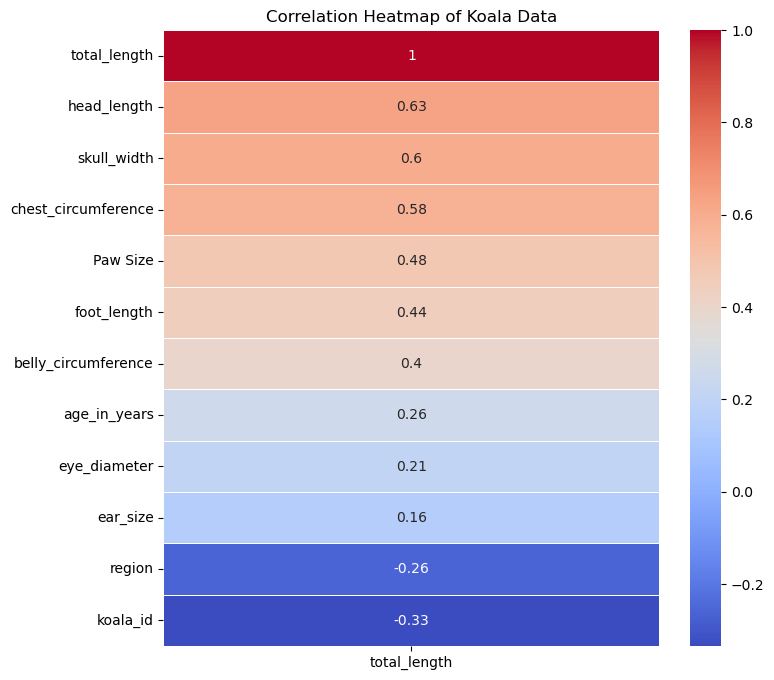

In [42]:
# Create a heatmap using seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix_sorted, annot=True, cmap='coolwarm', linewidths=0.5)

# Add a title
plt.title('Correlation Heatmap of Koala Data')

# Display the heatmap
plt.show()